# Case study 1: 9 DOF = 3 x 3-DOF

Three 3-DOF subsystems with three different filters and tasks: the grounded subsystem only tracks its states with a linear KF, the free-floating middle one identifies a stiffness from two accelerometers with a UKF, and the last one identifies a stiffness and a damping from a displacement and an acceleration sensor with a CKF and RK4.

The chain has non-uniform masses, stiffnesses and dampings, random forces act on
every mass, and messages are mean interface forces exchanged with the
**jacobi** schedule. The measurement covariance is inflated
10x to account for the message error (see [Concepts](../concepts.md)).

The paper-length horizon is 20 s at 1 ms; set `PCI_T` to shorten it. Set
`RUN_CENTRAL = True` to also run a single UKF on the full augmented state for
comparison.

In [1]:
import os

from _support import build, centralized, compare_with_yaml, print_design, report

N_DOF = 9
PARTITION = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
NAMES = ['S1', 'S2', 'S3']
SCHEDULE = "jacobi"
DT, T = 1e-3, float(os.environ.get("PCI_T", 20.0))
R_INFLATION = 10.0     # R = (10 x sensor noise)^2, needed with mean-only messages
RUN_CENTRAL = False

## Design: one line per subsystem

Filter, integrator, sensors with their noise standard deviation, and the unknowns as
a fraction of the true value used for the initial guess.

In [2]:
DESIGN = [
    dict(filter='kf', integrator='heun', sensors={'a1': 0.005, 'a3': 0.005}, unknowns={}),  # grounded: accelerations only, states only (linear KF)
    dict(filter='ukf', integrator='heun', sensors={'a5': 0.01, 'a6': 0.01}, unknowns={'k5': 0.6}),  # free-floating, two accelerometers, joint estimation
    dict(filter='ckf', integrator='rk4', sensors={'x8': 0.001, 'a9': 0.005}, unknowns={'k9': 0.7, 'c9': 1.5}),  # displacement + acceleration, two unknowns, RK4
]
LOADS = {1: {"type": "harmonic", "amplitude": 300.0, "frequency": 1.2}}
LOADS.update({d: {"type": "random", "std": 400.0, "seed": 10 + d} for d in range(1, N_DOF + 1)})

## Physical system, synthetic data, decomposition

In [3]:
chain, truth_dict, data, system, unknowns, sensors, noise = build(N_DOF, PARTITION, NAMES, DESIGN, LOADS, DT, T, SCHEDULE, R_INFLATION)
print_design("9 DOF = 3 x 3-DOF", NAMES, PARTITION, DESIGN, DT, T, SCHEDULE, R_INFLATION)

9 DOF = 3 x 3-DOF   schedule = jacobi   dt = 0.001   T = 20.0 s   steps = 20000   R inflation = 10x
----------------------------------------------------------------------------------------------------
subsystem DOFs              filter  integrator  task                      sensors (noise std)                     
S1        [1, 2, 3]         kf      heun        state estimation          a1 (0.005), a3 (0.005)                  
S2        [4, 5, 6]         ukf     heun        joint: k5                 a5 (0.01), a6 (0.01)                    
S3        [7, 8, 9]         ckf     rk4         joint: k9, c9             x8 (0.001), a9 (0.005)                  


## Distributed estimation

In [4]:
res = system.estimate(data, loads={f"f{d}": v for d, v in LOADS.items()}, dt=DT, T=T, truth=truth_dict)
report(res, chain.parameters, unknowns, NAMES, PARTITION, T)

Distributed run time: 10.8 s (sequential; ~3.6 s with one core per subsystem)

parameter       true   initial       final  error %  post. std
k5           52689.0   31613.4     52503.4    -0.35        326
k9           40475.2   28332.6     40608.4    +0.33        227
c9             278.1     417.2       285.7    +2.74       19.3

subsystem   disp. NRMSE (2nd half)   vel. NRMSE (2nd half)
S1                          0.069%                  0.088%
S2                          0.060%                  0.083%
S3                          0.051%                  0.078%
interface-force NRMSE (2nd half): F_k4 0.11%, F_k7 0.12%


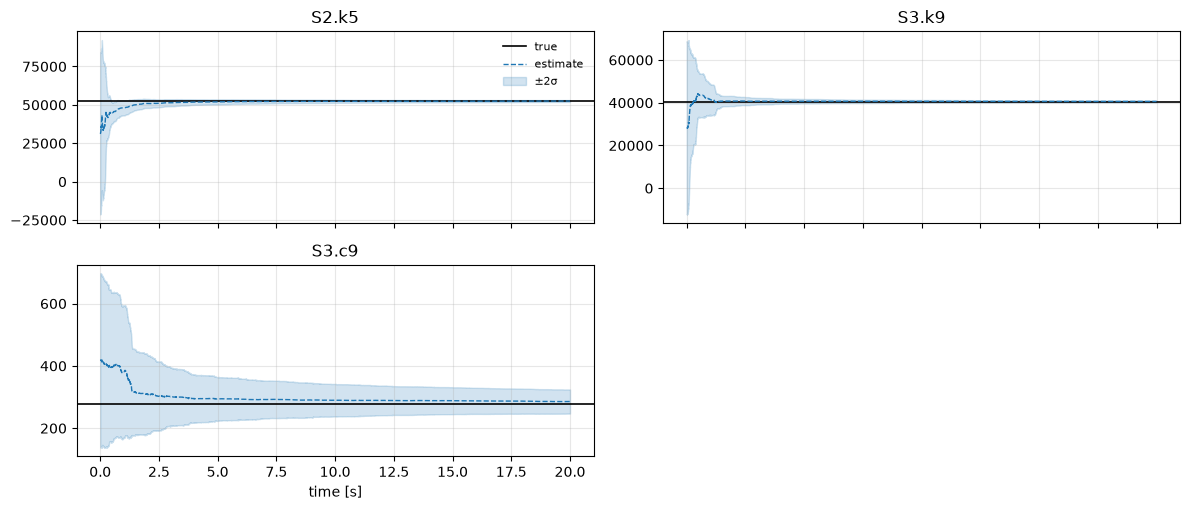

In [5]:
res.plot_parameters();

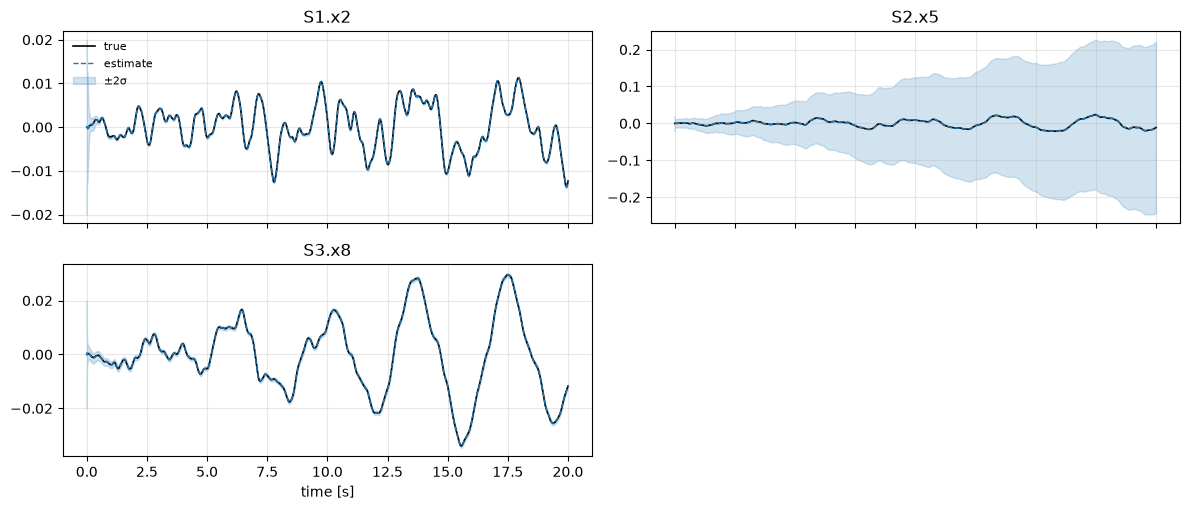

In [6]:
res.plot_states([f"{name}.x{g[len(g) // 2]}" for name, g in zip(NAMES, PARTITION)][:6]);

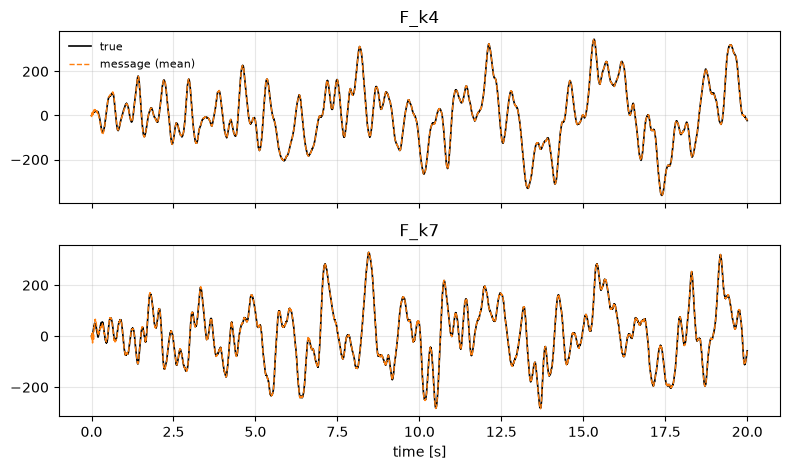

In [7]:
res.plot_messages();

## Centralized comparison (optional)

In [8]:
if RUN_CENTRAL:
    centralized(chain, N_DOF, unknowns, sensors, noise, data, LOADS, DT, T, truth_dict, R_INFLATION, res)

## The YAML twin

`01_case_09dof.yaml` describes the identical problem; with the full 20 s horizon it
reproduces the Python-API result to machine precision.

In [9]:
if T == 20.0:
    compare_with_yaml(res, "01_case_09dof.yaml", unknowns)

YAML twin (01_case_09dof.yaml): k5=52503.4, k9=40608.4, c9=285.7   max relative difference to Python API: 0.00e+00


The three schedules give the same parameters on this case; Jacobi and AB2 give the smallest state errors. The centralized UKF on the full augmented state agrees with the distributed estimates (k5 about -0.4 % in both) at 2-3x the sequential cost and without the one-core-per-subsystem speed-up.